In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings('ignore')

np.random.seed(42)

## Task 1

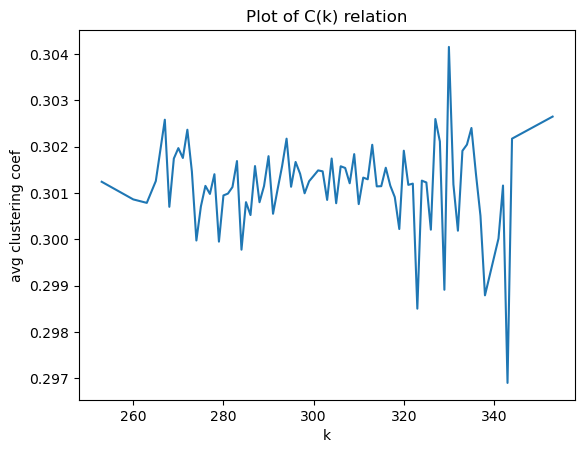

In [2]:
def plot_c(G):
    clust = np.array([v for k, v in nx.clustering(G).items()])
    degrees = np.array([d for _, d in G.degree()])
    
    k_values = np.unique(degrees)
    
    c_values = []
    for k in k_values:
        c = clust[degrees == k].mean()
        c_values.append(c)
        
    plt.plot(k_values, c_values)
    plt.title("Plot of C(k) relation")
    plt.xlabel("k")
    plt.ylabel("avg clustering coef")
    
G = nx.erdos_renyi_graph(n=1000, p=0.3)
plot_c(G)
plt.show()

## Task 2

In [3]:
# https://networkrepository.com/netscience.php

G = nx.read_weighted_edgelist("data/netscience_clean.mtx", nodetype=int)
print(G.number_of_nodes(), G.number_of_edges())

1461 2742


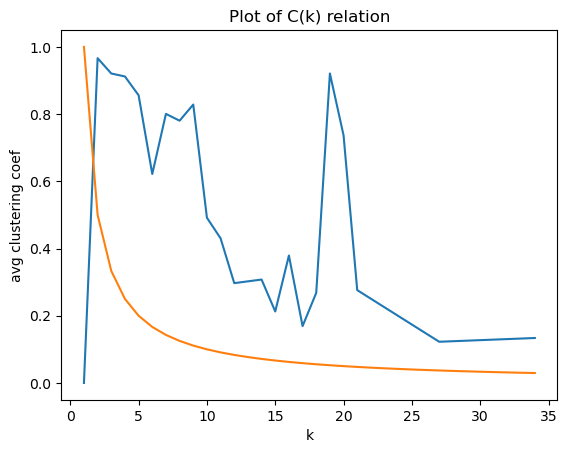

In [4]:
ks = np.arange(1, 35)
plot_c(G)
plt.plot(ks, 1/ks)
plt.show()

# non-hierarchical

In [5]:
# https://networkrepository.com/bio-celegans-dir.php

file_path = "data/bio-celegans-dir.edges"

G = nx.Graph()

with open(file_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 2:
            continue
        u, v = parts
        u, v = int(u), int(v)
        G.add_edge(u, v)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 453
Number of edges: 2040


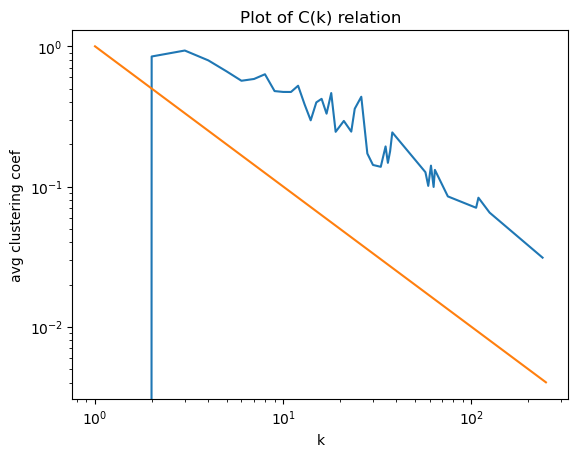

In [6]:
ks = np.arange(1, 250)
plot_c(G)
plt.xscale("log")
plt.yscale("log")
plt.plot(ks, 1/ks)
plt.show()

# hierarchical

In [7]:
# https://networkrepository.com/bn-fly-drosophila-medulla-1.php

file_path = "data/ca-cit-HepPh.edges"

G = nx.Graph()

with open(file_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('%'):
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        u, v = int(parts[0]), int(parts[1])
        G.add_edge(u, v)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 28093
Number of edges: 3148447


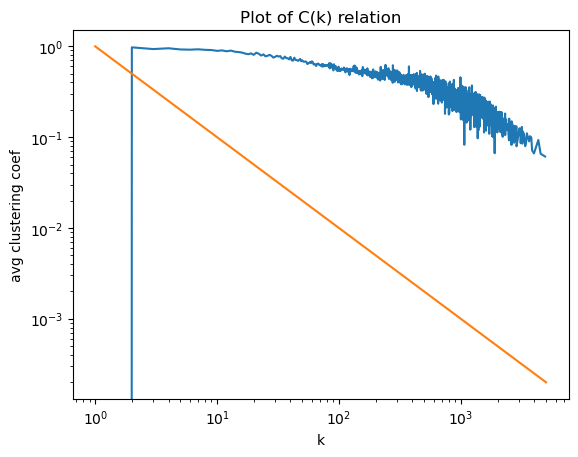

In [8]:
ks = np.arange(1, 5000)
plot_c(G)
plt.xscale("log")
plt.yscale("log")
plt.plot(ks, 1/ks)
plt.show()

# hierarchical

## Task 3

In [252]:
stops = pd.read_csv("data/gfts/stops.txt")
stops.head()

,stop_id,stop_code,stop_name,stop_lat,stop_lon
0,5,02,Radarowa,52.188762,20.962959
1,6,01,Radarowa,52.188116,20.964077
2,7,01,Hynka,52.190665,20.958908
3,8,02,Hynka,52.189708,20.957438
4,11,01,PKP Rakowiec,52.197993,20.965464


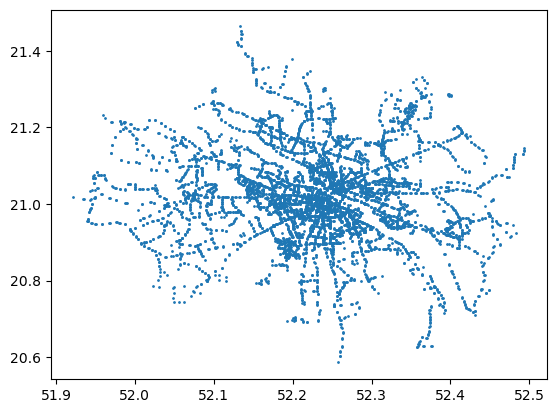

In [253]:
plt.scatter(stops["stop_lat"], stops["stop_lon"], s=1)
plt.show()

In [254]:
routes = pd.read_csv("data/gfts/routes.txt")
trips = pd.read_csv("data/gfts/trips.txt")
stop_times = pd.read_csv("data/gfts/stop_times.txt")

In [255]:
# adding trip_id
stops1 = stops.merge(stop_times[["stop_id", "trip_id"]], on='stop_id', how='left')
# adding route_id
stops2 = stops1.merge(trips[["trip_id", "route_id"]], on='trip_id', how='left')
# adding route_type
stops3 = stops2.merge(routes[["route_id", "route_type", "route_desc"]], on='route_id', how='left')

stops3.head()

,stop_id,stop_code,stop_name,stop_lat,stop_lon,trip_id,route_id,route_type,route_desc
0,5,02,Radarowa,52.188762,20.962959,0_2_4741317,0_141,3.0,P+R AL. KRAKOWSKA - al. Krakowska - Hynka - Żwirki i Wigury - Racławicka - Odyńca - Puławska - Dolna - Chełmska - Czerniakowska - most Łazienkowski - al. Stanów Zjednoczonych - Grochowska - Zamieniecka - Łukowska - WITOLIN|WITOLIN - Zamieniecka - Grochowska - al. Stanów Zjednoczonych - most Łazienkowski - Solec - Czerniakowska - Chełmska - Dolna - Puławska - Odyńca - Racławicka - Żwirki i Wigury - Hynka - al. Krakowska - P+R AL. KRAKOWSKA
1,5,02,Radarowa,52.188762,20.962959,0_2_4741319,0_141,3.0,P+R AL. KRAKOWSKA - al. Krakowska - Hynka - Żwirki i Wigury - Racławicka - Odyńca - Puławska - Dolna - Chełmska - Czerniakowska - most Łazienkowski - al. Stanów Zjednoczonych - Grochowska - Zamieniecka - Łukowska - WITOLIN|WITOLIN - Zamieniecka - Grochowska - al. Stanów Zjednoczonych - most Łazienkowski - Solec - Czerniakowska - Chełmska - Dolna - Puławska - Odyńca - Racławicka - Żwirki i Wigury - Hynka - al. Krakowska - P+R AL. KRAKOWSKA
2,5,02,Radarowa,52.188762,20.962959,0_2_4741323,0_141,3.0,P+R AL. KRAKOWSKA - al. Krakowska - Hynka - Żwirki i Wigury - Racławicka - Odyńca - Puławska - Dolna - Chełmska - Czerniakowska - most Łazienkowski - al. Stanów Zjednoczonych - Grochowska - Zamieniecka - Łukowska - WITOLIN|WITOLIN - Zamieniecka - Grochowska - al. Stanów Zjednoczonych - most Łazienkowski - Solec - Czerniakowska - Chełmska - Dolna - Puławska - Odyńca - Racławicka - Żwirki i Wigury - Hynka - al. Krakowska - P+R AL. KRAKOWSKA
3,5,02,Radarowa,52.188762,20.962959,0_2_4741325,0_141,3.0,P+R AL. KRAKOWSKA - al. Krakowska - Hynka - Żwirki i Wigury - Racławicka - Odyńca - Puławska - Dolna - Chełmska - Czerniakowska - most Łazienkowski - al. Stanów Zjednoczonych - Grochowska - Zamieniecka - Łukowska - WITOLIN|WITOLIN - Zamieniecka - Grochowska - al. Stanów Zjednoczonych - most Łazienkowski - Solec - Czerniakowska - Chełmska - Dolna - Puławska - Odyńca - Racławicka - Żwirki i Wigury - Hynka - al. Krakowska - P+R AL. KRAKOWSKA
4,5,02,Radarowa,52.188762,20.962959,0_2_4741329,0_141,3.0,P+R AL. KRAKOWSKA - al. Krakowska - Hynka - Żwirki i Wigury - Racławicka - Odyńca - Puławska - Dolna - Chełmska - Czerniakowska - most Łazienkowski - al. Stanów Zjednoczonych - Grochowska - Zamieniecka - Łukowska - WITOLIN|WITOLIN - Zamieniecka - Grochowska - al. Stanów Zjednoczonych - most Łazienkowski - Solec - Czerniakowska - Chełmska - Dolna - Puławska - Odyńca - Racławicka - Żwirki i Wigury - Hynka - al. Krakowska - P+R AL. KRAKOWSKA


In [256]:
stops3.route_type.unique()

array([ 3.,  0.,  2., nan])

In [257]:
routes[routes.route_type == 0] # trams

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type
117,0_1,2,1,NaN,ANNOPOL - Annopol - Rembielińska - Matki Teresy z Kalkuty - Odrowąża - Starzyńskiego - most Gdański - Słomińskiego - Okopowa - Towarowa - Grójecka - al. Krakowska - P+R AL. KRAKOWSKA|P+R AL. KRAKOWSKA - Grójecka - Towarowa - Okopowa - Słomińskiego - most Gdański - Starzyńskiego - Odrowąża - Matki Teresy z Kalkuty - Rembielińska - Annopol - ANNOPOL,0
118,0_2,2,2,NaN,METRO MŁOCINY - Kasprowicza - Nocznickiego - Zgrupowania AK „Kampinos” - al. płk. Kuklińskiego - Trakt Nadwiślański - Światowida - WINNICA|WINNICA - Trakt Nadwiślański - al. płk. Kuklińskiego - Zgrupowania AK „Kampinos” - Kasprowicza - METRO MŁOCINY,0
119,0_3,2,3,NaN,ANNOPOL - Annopol - Rembielińska - Matki Teresy z Kalkuty - Odrowąża - 11 Listopada - Targowa - Zamoyskiego - Grochowska - GOCŁAWEK|GOCŁAWEK - Targowa - 11 Listopada - Odrowąża - Matki Teresy z Kalkuty - Rembielińska - Annopol - ANNOPOL,0
120,0_4,2,4,NaN,ŻERAŃ WSCHODNI - Rembielińska - Matki Teresy z Kalkuty - Odrowąża - 11 Listopada - al. „Solidarności” - pl. Bankowy - Marszałkowska - Puławska - WYŚCIGI|WYŚCIGI - Marszałkowska - pl. Konstytucji - Marszałkowska - pl. Bankowy - al. „Solidarności” - Targowa - 11 Listopada - Odrowąża - Matki Teresy z Kalkuty - Rembielińska - Annopol - ŻERAŃ WSCHODNI,0
121,0_6,2,6,NaN,METRO MŁOCINY - Nocznickiego - Zgrupowania AK „Kampinos” - Marymoncka - Słowackiego - Mickiewicza - Andersa - Międzyparkowa - Słomińskiego - most Gdański - Starzyńskiego - Jagiellońska - Targowa - Zamoyskiego - Grochowska - GOCŁAWEK|GOCŁAWEK - Targowa - Jagiellońska - Starzyńskiego - most Gdański - Słomińskiego - Międzyparkowa - Andersa - Mickiewicza - Słowackiego - Marymoncka - Zgrupowania AK „Kampinos” - Nocznickiego - METRO MŁOCINY,0
...,...,...,...,...,...,...
2445,7_24,2,24,NaN,NOWE BEMOWO - Radiowa - Dywizjonu 303 - Obozowa - Młynarska - al. „Solidarności” - Towarowa - Al. Jerozolimskie - al. Poniatowskiego - al. Waszyngtona - rondo Wiatraczna - Grochowska - GOCŁAWEK|GOCŁAWEK - al. Waszyngtona - al. Poniatowskiego - Al. Jerozolimskie - Towarowa - al. „Solidarności” - Młynarska - Obozowa - Dywizjonu 303 - Radiowa - Powstańców Śląskich - NOWE BEMOWO,0
2446,7_26,2,26,NaN,METRO MŁOCINY - Nocznickiego - Kasprowicza - Nocznickiego - Wólczyńska - Broniewskiego - al. Reymonta - Powstańców Śląskich - Połczyńska - Wolska - al. „Solidarności” - Targowa - Zamoyskiego - Grochowska - rondo Wiatraczna - WIATRACZNA|WIATRACZNA - Grochowska - Targowa - al. „Solidarności” - Wolska - Połczyńska - Powstańców Śląskich - al. Reymonta - Wólczyńska - Nocznickiego - METRO MŁOCINY,0
2447,7_27,2,27,NaN,METRO MARYMONT - Słowackiego - ks. Popiełuszki - pl. Grunwaldzki - al. Jana Pawła II - Okopowa - al. „Solidarności” - Wolska - CM. WOLSKI|CM. WOLSKI - al. „Solidarności” - Okopowa - al. Jana Pawła II - pl. Grunwaldzki - ks. Popiełuszki - Słowackiego - METRO MARYMONT,0
2448,7_28,2,28,NaN,DW. WSCHODNI (KIJOWSKA) - Kijowska - Targowa - Jagiellońska - Starzyńskiego - most Gdański - Słomińskiego - al. Jana Pawła II - Broniewskiego - al. Reymonta - Powstańców Śląskich - Górczewska - OS. GÓRCZEWSKA|OS. GÓRCZEWSKA - Powstańców Śląskich - al. Reymonta - Broniewskiego - al. Jana Pawła II - Słomińskiego - most Gdański - Starzyńskiego - Jagiellońska - Targowa - Kijowska - DW. WSCHODNI (KIJOWSKA),0


In [258]:
routes[routes.route_type == 2] # trains

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type
0,0_A1,5,A1,NaN,WARSZAWA ŚRÓDMIEŚCIE WKD - Opacz-Kolonia/ - WKD/ - WKD GRODZISK MAZOWIECKI RADOŃSKA|WKD MILANÓWEK GRUDÓW - Opacz-Kolonia/ - WARSZAWA ŚRÓDMIEŚCIE WKD|WKD GRODZISK MAZOWIECKI RADOŃSKA - WKD/ - Opacz-Kolonia/ - WARSZAWA ŚRÓDMIEŚCIE WKD,2
1,0_A12,5,A12,NaN,WARSZAWA ŚRÓDMIEŚCIE WKD - WKD/ - WKD MILANÓWEK GRUDÓW,2
87,0_R1,5,R1,NaN,WARSZAWA WSCHODNIA - Piastów/ - Pruszków/ - PKP/ - PKP GRODZISK MAZOWIECKI|WARSZAWA GŁÓWNA - Piastów/ - Pruszków/ - PKP/ - PKP GRODZISK MAZOWIECKI|WARSZAWA WSCHODNIA - Piastów/ - Pruszków/ - PKP/ - PKP ŻYRARDÓW|WARSZAWA WSCHODNIA - Piastów/ - Pruszków/ - PKP/ - PKP SKIERNIEWICE|PKP DĘBLIN - Otwock/ - Józefów/ - Piastów/ - Pruszków/ - PKP/ - PKP GRODZISK MAZOWIECKI|PKP SOBOLEW - Otwock/ - Józefów/ - Piastów/ - Pruszków/ - PKP/ - PKP GRODZISK MAZOWIECKI|PKP DĘBLIN - Otwock/ - Józefów/ - Piastów/ - Pruszków/ - PKP/ - PKP ŻYRARDÓW|PKP GRODZISK MAZOWIECKI - Pruszków/ - Piastów/ - WARSZAWA WSCHODNIA|PKP GRODZISK MAZOWIECKI - PKP/ - Pruszków/ - Piastów/ - WARSZAWA GŁÓWNA|PKP ŻYRARDÓW - PKP/ - Pruszków/ - Piastów/ - WARSZAWA WSCHODNIA|PKP SKIERNIEWICE - PKP/ - Pruszków/ - Piastów/ - WARSZAWA WSCHODNIA|PKP MROZY - PKP/ - Sulejówek/ - Piastów/ - Pruszków/ - PKP/ - PKP GRODZISK MAZOWIECKI|PKP PILAWA - Otwock/ - Józefów/ - Piastów/ - Pruszków/ - PKP/ - PKP GRODZISK MAZOWIECKI|PKP CELESTYNÓW - Otwock/ - Józefów/ - Piastów/ - Pruszków/ - PKP/ - PKP GRODZISK MAZOWIECKI|WARSZAWA REMBERTÓW - Piastów/ - Pruszków/ - PKP/ - PKP GRODZISK MAZOWIECKI|PKP CELESTYNÓW - Otwock/ - Józefów/ - Piastów/ - Pruszków/ - PKP/ - PKP ŻYRARDÓW|WARSZAWA REMBERTÓW - Piastów/ - Pruszków/ - PKP/ - PKP ŻYRARDÓW|WARSZAWA FALENICA - Piastów/ - Pruszków/ - PKP/ - PKP SKIERNIEWICE|OTWOCK OTWOCK - Otwock/ - Józefów/ - Piastów/ - Pruszków/ - PKP/ - PKP SKIERNIEWICE,2
88,0_R2,5,R2,NaN,WARSZAWA ZACHODNIA - WARSZAWA REMBERTÓW|WARSZAWA ZACHODNIA - Sulejówek/ - PKP/ - PKP MIŃSK MAZ.|WARSZAWA ZACHODNIA - Sulejówek/ - PKP/ - PKP MROZY|WARSZAWA ZACHODNIA - Sulejówek/ - PKP/ - PKP SIEDLCE|WARSZAWA ZACHODNIA - Sulejówek/ - PKP/ - PKP ŁUKÓW|WARSZAWA REMBERTÓW - WARSZAWA ZACHODNIA|PKP MIŃSK MAZ. - Sulejówek/ - WARSZAWA ZACHODNIA|PKP MROZY - PKP/ - Sulejówek/ - WARSZAWA ZACHODNIA|PKP SIEDLCE - PKP/ - Sulejówek/ - WARSZAWA ZACHODNIA|PKP ŁUKÓW - PKP/ - Sulejówek/ - WARSZAWA ZACHODNIA|PKP GRODZISK MAZOWIECKI - PKP/ - Pruszków/ - Piastów/ - WARSZAWA REMBERTÓW|PKP ŻYRARDÓW - PKP/ - Pruszków/ - Piastów/ - WARSZAWA REMBERTÓW|PKP ŁOWICZ GŁÓWNY - PKP/ - Płochocin/ - Ożarów Mazowiecki/ - WARSZAWA REMBERTÓW|PKP SOCHACZEW - PKP/ - Płochocin/ - Ożarów Mazowiecki/ - WARSZAWA REMBERTÓW|PKP BŁONIE - PKP/ - Płochocin/ - Ożarów Mazowiecki/ - Sulejówek/ - PKP/ - PKP MIŃSK MAZ.|PKP SOCHACZEW - Płochocin/ - Ożarów Mazowiecki/ - Sulejówek/ - PKP/ - PKP MIŃSK MAZ.|PKP GRODZISK MAZOWIECKI - Pruszków/ - Piastów/ - Sulejówek/ - PKP/ - PKP MIŃSK MAZ.|PKP ŻYRARDÓW - Pruszków/ - Piastów/ - Sulejówek/ - PKP/ - PKP MIŃSK MAZ.,2
89,0_R3,5,R3,NaN,WARSZAWA WSCHODNIA - Ożarów Mazowiecki/ - Płochocin/ - PKP/ - PKP ŁOWICZ GŁÓWNY|WARSZAWA WSCHODNIA - Ożarów Mazowiecki/ - Płochocin/ - PKP/ - PKP SOCHACZEW|WARSZAWA WSCHODNIA - Ożarów Mazowiecki/ - Płochocin/ - PKP/ - PKP BŁONIE|PKP DĘBLIN - Otwock/ - Józefów/ - Ożarów Mazowiecki/ - OŻARÓW MAZOWIECKI OŻARÓW MAZOWIECKI|PKP ŁOWICZ GŁÓWNY - PKP/ - Płochocin/ - Ożarów Mazowiecki/ - WARSZAWA WSCHODNIA|PKP SOCHACZEW - PKP/ - Płochocin/ - Ożarów Mazowiecki/ - WARSZAWA WSCHODNIA|PKP BŁONIE - PKP/ - Płochocin/ - Ożarów Mazowiecki/ - WARSZAWA WSCHODNIA|OŻARÓW MAZOWIECKI OŻARÓW MAZOWIECKI - WARSZAWA WSCHODNIA|PKP SIEDLCE - PKP/ - Sulejówek/ - Ożarów Mazowiecki/ - Płochocin/ - PKP/ - PKP ŁOWICZ GŁÓWNY|OTWOCK OTWOCK - Otwock/ - Józefów/ - Ożarów Mazowiecki/ - Płochocin/ - PKP/ - PKP ŁOWICZ GŁÓWNY|PKP MROZY - Sulejówek/ - Ożarów Mazowiecki/ - Płochocin/ - PKP/ - PKP SOCHACZEW|PKP MIŃSK MAZ. - Sulejówek/ - Ożarów Mazowiecki/ - Płochocin/ - PKP/ - PKP SOCHACZEW|WARSZAWA REMBERTÓW - 

In [259]:
routes[routes.route_type == 3] # mixed

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type
2,0_E-1,2,E-1,NaN,METRO STADION NARODOWY - Sokola - Zwycięzców - Saska - Bora-Komorowskiego - GOCŁAW|GOCŁAW - Egipska - Saska - Zwycięzców - Sokola - METRO STADION NARODOWY,3
3,0_E-2,2,E-2,NaN,METRO RATUSZ ARSENAŁ - al. „Solidarności” - pl. Bankowy - Krakowskie Przedmieście - Nowy Świat - Al. Ujazdowskie - Sobieskiego - al. Wilanowska - Przyczółkowa - WILANÓW|WILANÓW - al. Wilanowska - Sobieskiego - Belwederska - Al. Ujazdowskie - pl. Trzech Krzyży - Nowy Świat - Krakowskie Przedmieście - al. „Solidarności” - METRO RATUSZ ARSENAŁ,3
4,0_L-1,2,L-1,NaN,PIASECZNO PKP PIASECZNO - Piaseczno/Towarowa - Piaseczno/Dworcowa - Piaseczno/Jana Pawła II - Piaseczno/Orężna - Łoziska/Leśna - Jazgarzewszczyzna/Leśna - Kolonia Lesznowola/Mazowiecka - Bobrowiec/Żwirowa - Wilcza Góra/Żwirowa - Władysławów/Wojska Polskiego - Kuleszówka/Masztowa - Łazy/Lokalna - Łazy/ks. Słojewskiego - Magdalenka/ks. Słojewskiego - Magdalenka/Lipowa - Magdalenka/Słoneczna - Lesznowola/Słoneczna - Lesznowola/Gminna - Lesznowola/Jedności - Janczewice/Jedności - Falenty/al. Hrabska - Janki/pl. Szwedzki - JANKI PL. SZWEDZKI|JANKI PL. SZWEDZKI - Janki/Mszczonowska - Janczewice/Jedności - Lesznowola/Jedności - Lesznowola/Słoneczna - Lesznowola/Gminna - Lesznowola/Słoneczna - Magdalenka/Lipowa - Magdalenka/ks. Słojewskiego - Łazy/ks. Słojewskiego - Łazy/Wirażowa - Kuleszówka/Masztowa - Władysławów/Wojska Polskiego - Wilcza Góra/Żwirowa - Bobrowiec/Mazowiecka - Kolonia Lesznowola/Leśna - Jazgarzewszczyzna/Leśna - Łoziska/Leśna - Piaseczno/Orężna - Piaseczno/Jana Pawła II - Piaseczno/Dworcowa - Piaseczno/Towarowa - PIASECZNO PKP PIASECZNO,3
5,0_L10,2,L10,NaN,LEGIONOWO PKP LEGIONOWO - Legionowo/centrum komunikacyjne - Legionowo/Piłsudskiego - Legionowo/Sobieskiego - Legionowo/Krakowska - Legionowo/al. Legionów - Legionowo/Suwalna - Legionowo/Szarych Szeregów - Łajski/Fabryczna - Łajski/Kościelna - Wieliszew/Kościelna - Wieliszew/Modlińska - Wieliszew/Niepodległości - Wieliszew/por. Przedpełskiego - Komornica/Wspólna - Poddębie/Nasielska - Komornica/Nasielska - KOMORNICA KOMORNICA-SZKOŁA|KOMORNICA KOMORNICA-SZKOŁA - Poddębie/Nasielska - Komornica/Wspólna - Wieliszew/por. Przedpełskiego - Wieliszew/Niepodległości - Wieliszew/Słoneczna - Wieliszew/Modlińska - Wieliszew/Kościelna - Łajski/Kościelna - Łajski/Fabryczna - Legionowo/Szarych Szeregów - Legionowo/pętla os. Młodych - Legionowo/Suwalna - Legionowo/al. Legionów - Legionowo/al. Róż - Legionowo/Sobieskiego - Legionowo/Piłsudskiego - Legionowo/Jagiellońska - Legionowo/Słowackiego - Legionowo/centrum komunikacyjne - LEGIONOWO PKP LEGIONOWO,3
6,0_L11,2,L11,NaN,LEGIONOWO PKP LEGIONOWO - Legionowo/Piłsudskiego - Legionowo/Sowińskiego - Legionowo/Warszawska - Legionowo/Zegrzyńska - Michałów-Reginów/Warszawska - Michałów-Reginów/Nowodworska - Łajski/Kościelna - Wieliszew/Kościelna - Wieliszew/Modlińska - Wieliszew/Niepodległości - Wieliszew/por. Przedpełskiego - Wieliszew/Modlińska - Poniatów/Nowodworska - Skrzeszew/Kościelna - Skrzeszew/Nowodworska - Kałuszyn/Nowodworska - Olszewnica Stara/Warszawska - Olszewnica Stara/skwer 11 Listopada - Olszewnica Stara/Nowodworska - Olszewnica Nowa/Nowodworska - Krubin/Nowodworska - Janówek Pierwszy/Nowodworska - Góra/Nowodworska - Okunin/Okunin - Nowy Dwór Mazowiecki/Bohaterów Modlina - Nowy Dwór Mazowiecki/Sawy - NOWY DWÓR MAZOWIECKI URZĄD MIASTA|NOWY DWÓR MAZOWIECKI URZĄD MIASTA - Nowy Dwór Mazowiecki/Bohaterów Modlina - Okunin/Okunin - Góra/Nowodworska - Janówek Pierwszy/Nowodworska - Krubin/Nowodworska - Olszewnica Nowa/Nowodworska - Olszewnica Stara/Warszawska - Olszewnica Stara/skwer 11 Listopada - Olszewnica Stara/Nowodworska - Kałuszyn/Nowodworska - Skrzeszew/Szkolna - Skrzeszew/Kościelna - Poniatów/Nowodworska - Wieliszew/Modlińska - Wieliszew/por. Przedpełskiego - Wieliszew/Niepodległości - Wieliszew/Słoneczna - Wieliszew/Modlińska - Wieliszew/Kościelna - Łajski/Kościelna - Łajski/Nowodworska - Michałów-Reg

In [260]:
# simple detection of transport types
def detect_transport(route_str, route_type):
    if route_type == 0:
        return "Tram"
    if route_type == 2:
        return "Train"
    return "Other"
    # not distinguishable (e.g. name "METRO" may apper in buses)
    
    # if pd.isna(route_str):
    #     return 'unknown'
    # route_str = route_str.upper()
    # if 'METRO' in route_str:
    #     return 'Metro'
    # elif 'TRAM' in route_str:
    #     return 'Tram'
    # elif 'BUS' in route_str:
    #     return 'Bus'
    # elif 'RAIL' in route_str or 'PKP' in route_str or 'WKD' in route_str:
    #     return 'Train'
    # else:
    #     return 'Other'

stops3['transport_type'] = stops3.apply(
    lambda row: detect_transport(row['route_desc'], row['route_type']),
    axis=1
)
stops3['transport_type'] = stops3['transport_type'].fillna('unknown')

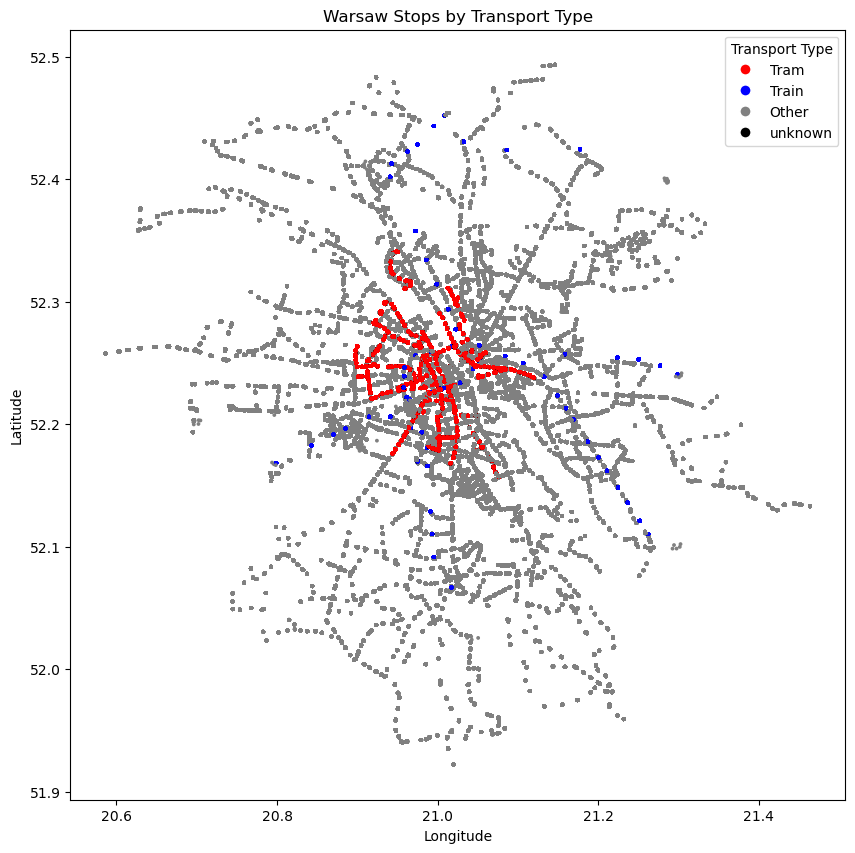

In [261]:
color_map = {
    'Tram': 'red',
    'Train': 'blue',
    # 'Bus': 'green',
    # 'Metro': 'purple',
    'Other': 'gray',
    'unknown': 'black'
}

colors = stops3['transport_type'].map(color_map).fillna('black')

plt.figure(figsize=(10, 10))
plt.scatter(
    stops3['stop_lon'],
    stops3['stop_lat'],
    c=colors.tolist(),
    s=3
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Warsaw Stops by Transport Type")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=mode,
           markerfacecolor=color, markersize=8)
    for mode, color in color_map.items()
]
plt.legend(handles=legend_elements, title="Transport Type")

plt.show()


In [262]:
stop_times

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
0,0_2_4745094,06:04:00,06:04:00,2228,0,NaN,0,1,0.000,1
1,0_2_4745094,06:05:00,06:05:00,3552,1,NaN,0,0,0.317,1
2,0_2_4745094,06:06:00,06:06:00,2226,2,NaN,0,0,0.576,1
3,0_2_4745094,06:07:00,06:07:00,2239,3,NaN,0,0,0.936,1
4,0_2_4745094,06:09:00,06:09:00,2223,4,NaN,0,0,1.566,1
...,...,...,...,...,...,...,...,...,...,...
6547234,7_3_4373020,15:24:00,15:24:00,6427,2,NaN,3,3,1.835,1
6547235,7_3_4373020,15:25:00,15:25:00,1701,3,NaN,0,0,2.254,1
6547236,7_3_4373020,15:26:00,15:26:00,1700,4,NaN,0,0,2.701,1
6547237,7_3_4373020,15:27:00,15:27:00,3669,5,NaN,3,3,3.071,1


In [263]:
edges = []

for trip_id, group in stop_times.groupby('trip_id'):
    group = group.sort_values('stop_sequence')
    stops_list = group['stop_id'].tolist()
    
    # create edges between consecutive stops
    for i in range(len(stops_list)-1):
        edges.append((stops_list[i], stops_list[i+1]))

edges = list(set(edges))

In [264]:
G = nx.Graph()
G.add_edges_from(edges)

for idx, row in stops3.iterrows():
    if row['stop_id'] in G:
        G.nodes[row['stop_id']]['pos'] = (row['stop_lon'], row['stop_lat'])
        G.nodes[row['stop_id']]['transport_type'] = row['transport_type']

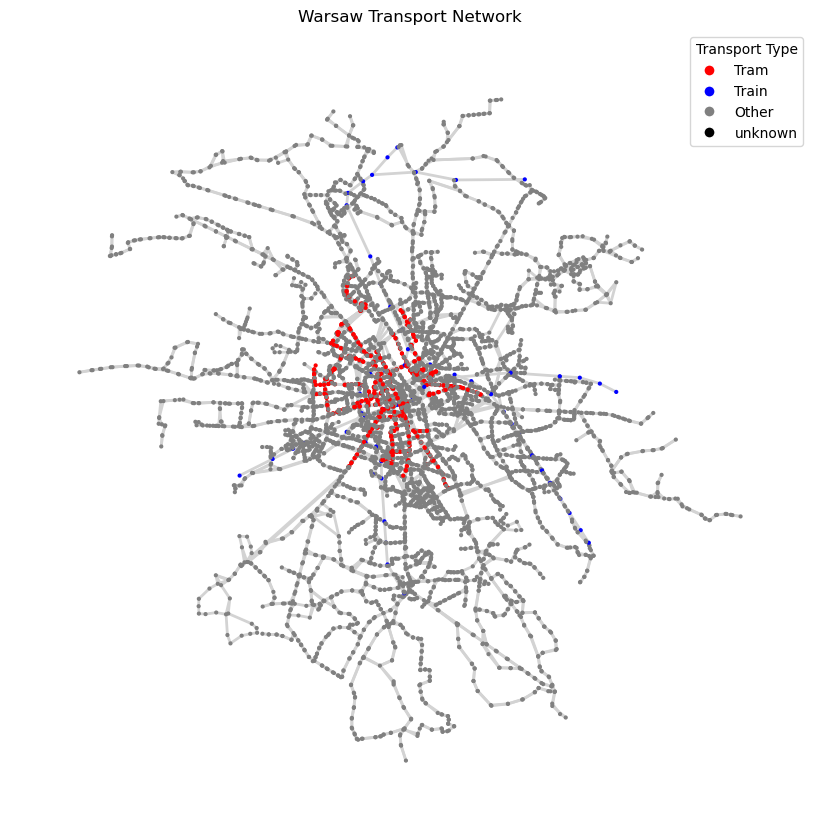

In [265]:
color_map = {
    'Tram': 'red',
    'Train': 'blue',
    'Other': 'gray',
    'unknown': 'black'
}

node_colors = [color_map.get(G.nodes[n]['transport_type'], 'black') for n in G.nodes()]

plt.figure(figsize=(8, 8))
pos = nx.get_node_attributes(G, 'pos')
nx.draw(
    G, 
    pos, 
    node_color=node_colors, 
    node_size=4,
    width=2,
    edge_color='lightgray', 
    with_labels=False
)

plt.title("Warsaw Transport Network")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=mode,
           markerfacecolor=color, markersize=8)
    for mode, color in color_map.items()
]
plt.legend(handles=legend_elements, title="Transport Type")

plt.show()

## Task 4

In [266]:
# basic characteristics for trams and trains

tram_nodes = [n for n, attr in G.nodes(data=True) if attr.get('transport_type') == 'Tram']
G_tram = G.subgraph(tram_nodes).copy()

train_nodes = [n for n, attr in G.nodes(data=True) if attr.get('transport_type') == 'Train']
G_train = G.subgraph(train_nodes).copy()

In [267]:
def compute_network_stats(G):
    stats = {}
    
    stats['num_nodes'] = G.number_of_nodes()
    stats['num_edges'] = G.number_of_edges()
    
    # degree
    degrees = np.array([d for n, d in G.degree()])
    stats['max_degree'] = degrees.max() if len(degrees) > 0 else 0
    stats['average_degree'] = degrees.mean() if len(degrees) > 0 else 0
    
    # clustering coef
    if len(G) > 0:
        clustering_vals = list(nx.clustering(G).values())
        stats['clustering_coef'] = np.mean(clustering_vals)
    else:
        stats['clustering_coef'] = 0
    
    # assortativity
    try:
        stats['assortativity'] = nx.degree_assortativity_coefficient(G)
    except:
        stats['assortativity'] = np.nan
    
    return stats


In [268]:
compute_network_stats(G_train)

{'num_nodes': 62,
 'num_edges': 63,
 'max_degree': 5,
 'average_degree': 2.032258064516129,
 'clustering_coef': 0.0,
 'assortativity': -0.05722891566264874}

In [269]:
compute_network_stats(G_tram)

{'num_nodes': 611,
 'num_edges': 745,
 'max_degree': 7,
 'average_degree': 2.4386252045826513,
 'clustering_coef': 0.002182214948172395,
 'assortativity': 0.008634571908419115}

In [270]:
compute_network_stats(G)

{'num_nodes': 6763,
 'num_edges': 8875,
 'max_degree': 13,
 'average_degree': 2.6245748927990538,
 'clustering_coef': 0.02117387926939901,
 'assortativity': 0.207922510376168}